# EnergyPlus MCP Evaluation — Retrospective Graphics

## How We Ran This

We built an evaluation framework to answer one question: **does giving an LLM structured MCP tools for EnergyPlus data produce better analysis than letting it figure things out with basic file tools?**

**The stack:**
- **Claude Code CLI** (`claude -p`) in headless mode, running each scenario as an isolated single-prompt session
- **4 prompts** of increasing complexity (2-model cross-reference up to 20-model batch analysis)
- **4 modes** varying the toolset available to the model:
  - `vanilla` — Bash/Read/Grep/Glob only (no MCP, no domain knowledge)
  - `prompt-only` — same tools, but with an EnergyPlus domain guide injected as system prompt
  - `mcp-pandas-exec` — MCP tools (model discovery, HTML tables, SQL timeseries, pandas execution)
  - `mcp-pandas-exec-plus` — MCP tools + pre-built aggregation helpers (get_end_uses, get_timeseries_stats)
- **3 models** — Haiku, Sonnet, Opus (Claude model family)
- **LLM-as-grader** — each prompt × mode × model output graded against hand-verified expected answers JSON on 5 dimensions (correctness, completeness, efficiency, insight, graceful degradation), scored 1-5 each for a 25-point total

**By the numbers:**
- 53 scenario runs + 20 grading passes = **73 total Claude Code sessions**
- **3.7 hours** of cumulative wall time across all runs
- 4 prompts × 4 modes × 3 models = 48 cells in the matrix (46 actually run; 2 prompt-04 combinations had no Sonnet result)

The primary comparison axis is **mode** (MCP vs non-MCP). Models are a secondary grouping.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 200, "figure.facecolor": "white"})

# ── Raw data from cross-model grade-models files ──────────────────────────────
records = [
    # prompt, mode, haiku, sonnet, opus, haiku_time, sonnet_time, opus_time
    ("01", "vanilla",           6,  24, 16,    9,   91,  137),
    ("01", "pandas-exec",      13,  25, 23,   37,   77,  107),
    ("01", "hybrid",           17,  25, 23,   86,   87,   98),
    ("01", "prompt-only",      17,  25, 20,   93,  102,  176),
    ("02", "vanilla",          14,  23, 23,  227,  197,  155),
    ("02", "pandas-exec",      19,  22, 20,   94,  289,  153),
    ("02", "hybrid",           21,  16, 24,  113,  281,  190),
    ("02", "prompt-only",      13,  25, 25,  149,  264,  157),
    ("03", "vanilla",          13,   7, 20,  171,  305,  540),
    ("03", "mcp-pandas-exec",  10,  15, 16,  156,  None, 270),
    ("03", "mcp-pandas-exec+", 11,  25, 18,  149,  None, 408),
    ("03", "prompt-only",      10,  19, 16,  170,  862,  144),
    ("04", "vanilla",          18,  20, 13,  331,  898,  298),
    ("04", "pandas-exec",       8, None, 24,  183, None,  325),
    ("04", "hybrid",           17,  23,  5,  460,  498,  389),
    ("04", "prompt-only",      11, None, 22,  196, None,  314),
]

rows = []
for prompt, mode, h, s, o, ht, st, ot in records:
    for model, score, time in [("Haiku", h, ht), ("Sonnet", s, st), ("Opus", o, ot)]:
        if score is not None:
            rows.append({"prompt": prompt, "mode": mode, "model": model,
                         "score": score, "time": time})

df = pd.DataFrame(rows)

# ── Categorize modes ──────────────────────────────────────────────────────────
# Normalize mode names (prompt 03 used different names)
mode_normalize = {
    "vanilla": "vanilla", "prompt-only": "prompt-only",
    "pandas-exec": "mcp-pandas-exec", "mcp-pandas-exec": "mcp-pandas-exec",
    "hybrid": "mcp-pandas-exec-plus", "mcp-pandas-exec+": "mcp-pandas-exec-plus",
}
df["mode_norm"] = df["mode"].map(mode_normalize)

# MCP vs non-MCP grouping
mcp_group = {
    "vanilla": "No MCP", "prompt-only": "No MCP",
    "mcp-pandas-exec": "MCP", "mcp-pandas-exec-plus": "MCP",
}
df["mcp_group"] = df["mode_norm"].map(mcp_group)

# Readable mode labels
mode_labels = {
    "vanilla": "Vanilla\n(no tools, no knowledge)",
    "prompt-only": "Prompt-Only\n(no tools, domain guide)",
    "mcp-pandas-exec": "MCP Pandas-Exec\n(MCP tools)",
    "mcp-pandas-exec-plus": "MCP Plus\n(MCP + aggregation)",
}
df["mode_label"] = df["mode_norm"].map(mode_labels)

# Palette
model_colors = {"Haiku": "#5B9BD5", "Sonnet": "#70AD47", "Opus": "#ED7D31"}
mcp_colors = {"No MCP": "#8B8B8B", "MCP": "#2E75B6"}
mode_colors = {
    "vanilla": "#A6A6A6",
    "prompt-only": "#BF9000",
    "mcp-pandas-exec": "#2E75B6",
    "mcp-pandas-exec-plus": "#1F4E79",
}

print(f"{len(df)} data points: {df['prompt'].nunique()} prompts × "
      f"{df['mode_norm'].nunique()} modes × {df['model'].nunique()} models")

46 data points: 4 prompts × 4 modes × 3 models


## 1. The Big Picture — MCP vs. No MCP

Score distributions grouped by whether MCP tools were available. Each dot is one prompt × model run.

/tmp/ipykernel_13058/892454735.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="mcp_group", y="score", order=group_order,
/tmp/ipykernel_13058/892454735.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="mode_norm", y="score", order=mode_order,
/tmp/ipykernel_13058/892454735.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([mode_short[m] for m in mode_order])


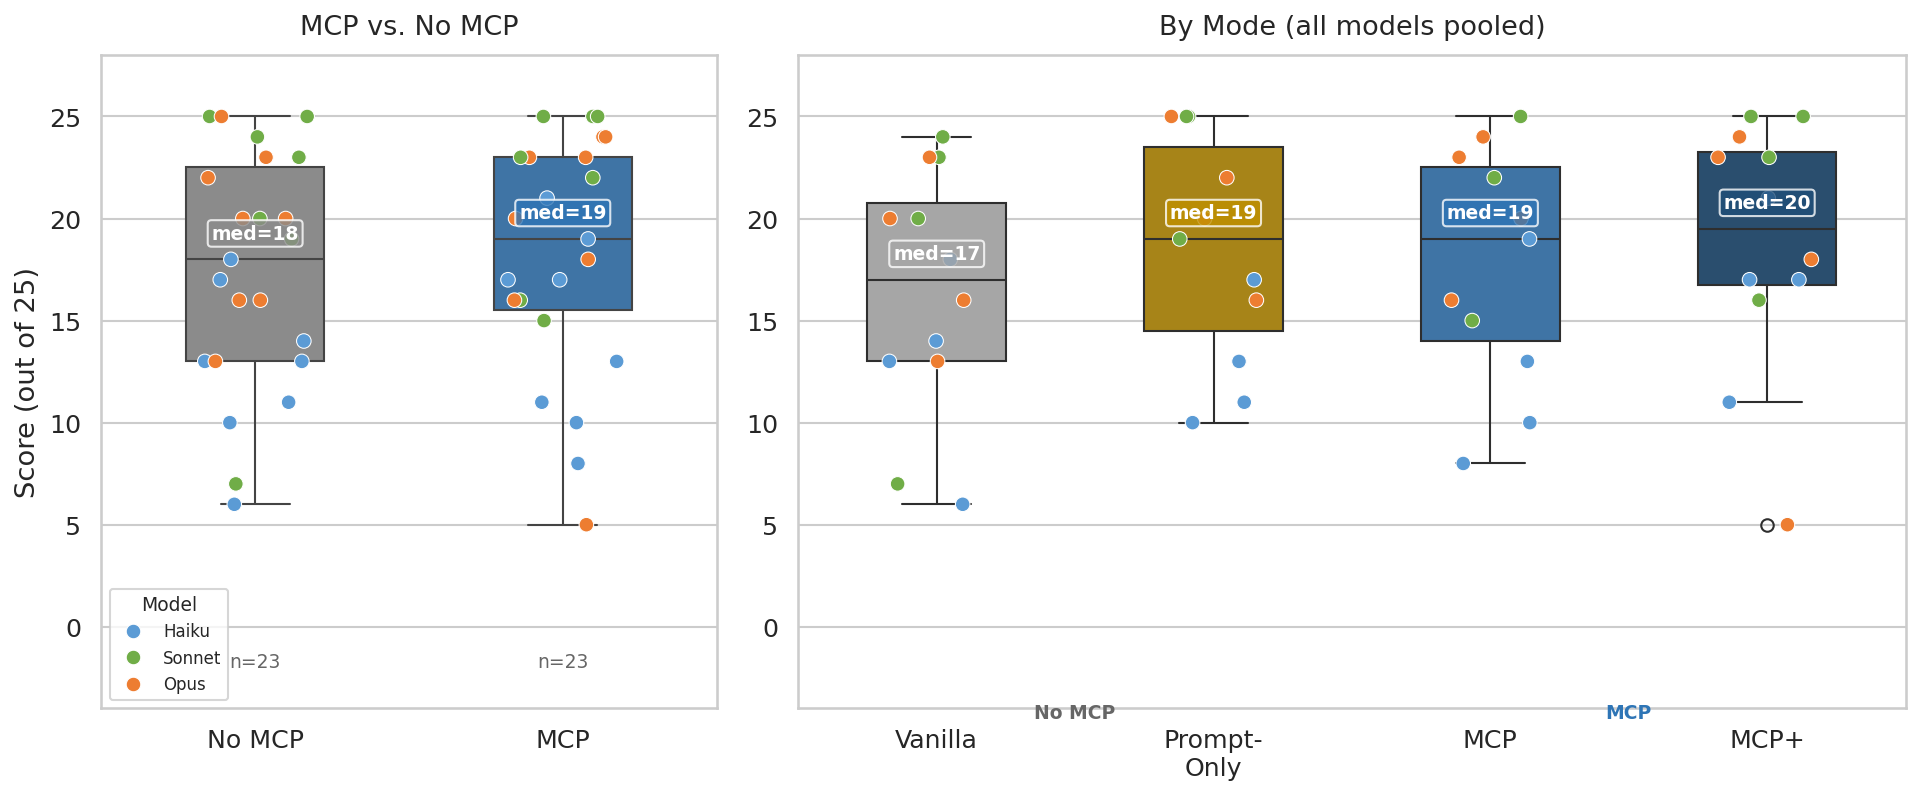

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [1, 1.8]})

# ── Left: MCP vs No MCP box plot ──
group_order = ["No MCP", "MCP"]
box_pal = [mcp_colors[g] for g in group_order]

sns.boxplot(data=df, x="mcp_group", y="score", order=group_order,
            palette=box_pal, width=0.45, ax=ax1, zorder=2)
sns.stripplot(data=df, x="mcp_group", y="score", order=group_order,
              hue="model", palette=model_colors, size=7, jitter=0.18,
              edgecolor="white", linewidth=0.5, ax=ax1, zorder=3)

for i, grp in enumerate(group_order):
    sub = df[df["mcp_group"] == grp]["score"]
    ax1.text(i, sub.median() + 1, f"med={sub.median():.0f}",
             ha="center", fontsize=9, fontweight="bold", color="white",
             bbox=dict(boxstyle="round,pad=0.2", fc=box_pal[i], alpha=0.8))
    ax1.text(i, -2, f"n={len(sub)}", ha="center", fontsize=9, color="#666")

ax1.set_ylabel("Score (out of 25)")
ax1.set_xlabel("")
ax1.set_title("MCP vs. No MCP", fontsize=13, pad=10)
ax1.set_ylim(-4, 28)
ax1.legend(title="Model", fontsize=8, title_fontsize=9, loc="lower left")

# ── Right: All 4 modes, broken out ──
mode_order = ["vanilla", "prompt-only", "mcp-pandas-exec", "mcp-pandas-exec-plus"]
mode_short = {"vanilla": "Vanilla", "prompt-only": "Prompt-\nOnly",
              "mcp-pandas-exec": "MCP", "mcp-pandas-exec-plus": "MCP+"}
mode_pal = [mode_colors[m] for m in mode_order]

sns.boxplot(data=df, x="mode_norm", y="score", order=mode_order,
            palette=mode_pal, width=0.5, ax=ax2, zorder=2)
sns.stripplot(data=df, x="mode_norm", y="score", order=mode_order,
              hue="model", palette=model_colors, size=7, jitter=0.18,
              edgecolor="white", linewidth=0.5, ax=ax2, zorder=3, legend=False)

for i, m in enumerate(mode_order):
    sub = df[df["mode_norm"] == m]["score"]
    ax2.text(i, sub.median() + 1, f"med={sub.median():.0f}",
             ha="center", fontsize=9, fontweight="bold", color="white",
             bbox=dict(boxstyle="round,pad=0.2", fc=mode_pal[i], alpha=0.8))

ax2.set_xticklabels([mode_short[m] for m in mode_order])
ax2.set_ylabel("")
ax2.set_xlabel("")
ax2.set_title("By Mode (all models pooled)", fontsize=13, pad=10)
ax2.set_ylim(-4, 28)

# Bracket labels
ax2.annotate("No MCP", xy=(0.5, -4.5), fontsize=9, ha="center", color="#666",
             fontweight="bold", annotation_clip=False)
ax2.annotate("MCP", xy=(2.5, -4.5), fontsize=9, ha="center", color="#2E75B6",
             fontweight="bold", annotation_clip=False)

plt.tight_layout()
plt.savefig("results/graphic_1_mcp_vs_no_mcp.png", bbox_inches="tight")
plt.show()

## 2. Heat Map — Full Matrix (Mode as Primary Axis)

Columns grouped by mode, rows by prompt × model. The color tells you whether MCP helped *this specific combination*.

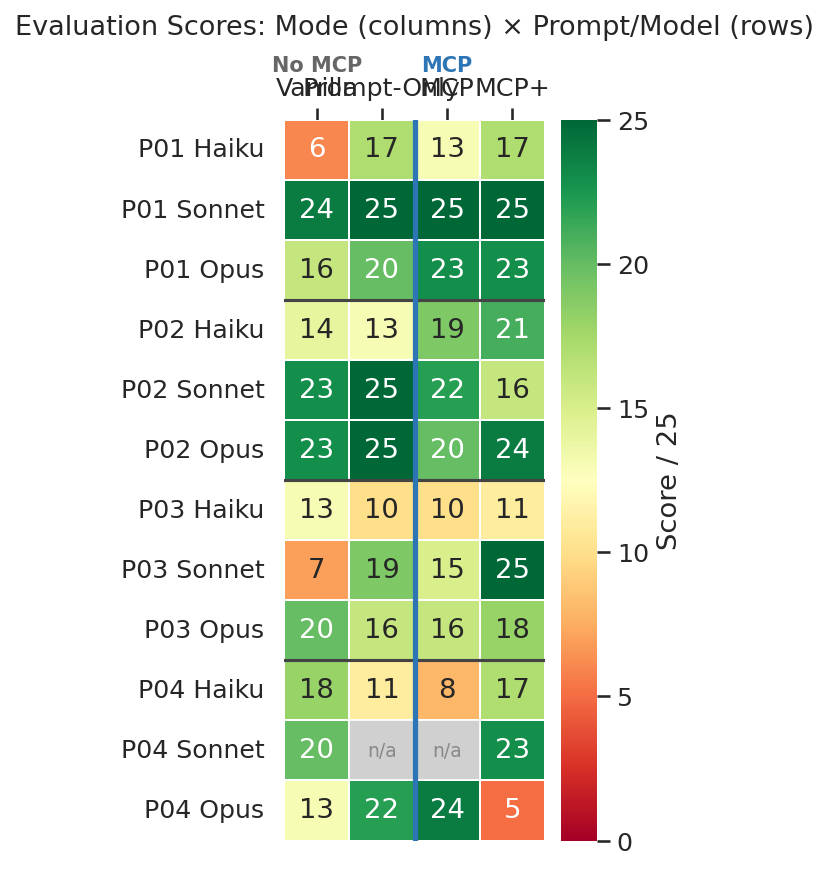

In [12]:
# Pivot: rows = prompt × model, columns = mode
df["row_label"] = "P" + df["prompt"] + " " + df["model"]
mode_col_order = ["vanilla", "prompt-only", "mcp-pandas-exec", "mcp-pandas-exec-plus"]
mode_col_names = ["Vanilla", "Prompt-Only", "MCP", "MCP+"]

pivot = df.pivot_table(index="row_label", columns="mode_norm", values="score", aggfunc="first")
pivot = pivot.reindex(columns=mode_col_order)
pivot.columns = mode_col_names

# Row ordering: prompt then model tier
row_order = [f"P{p} {m}" for p in ["01", "02", "03", "04"]
             for m in ["Haiku", "Sonnet", "Opus"]
             if f"P{p} {m}" in pivot.index]
pivot = pivot.loc[row_order]

fig, ax = plt.subplots(figsize=(4, 6))
cmap = sns.color_palette("RdYlGn", as_cmap=True)

sns.heatmap(pivot, annot=True, fmt=".0f", cmap=cmap, vmin=0, vmax=25,
            linewidths=0.8, linecolor="white", cbar_kws={"label": "Score / 25"},
            mask=pivot.isna(), ax=ax)

# Gray out missing cells
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        if pd.isna(pivot.iloc[i, j]):
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True,
                                        color="#d0d0d0", ec="white", lw=0.8))
            ax.text(j + 0.5, i + 0.5, "n/a", ha="center", va="center",
                    color="#888", fontsize=9)

# Prompt group separators
for sep in [3, 6, 9]:
    ax.axhline(sep, color="#444", lw=1.5)

# MCP/no-MCP column separator
ax.axvline(2, color="#2E75B6", lw=2.5)
ax.text(0.5, -0.8, "No MCP", ha="center", fontsize=10, fontweight="bold", color="#666")
ax.text(2.5, -0.8, "MCP", ha="center", fontsize=10, fontweight="bold", color="#2E75B6")

ax.set_title("Evaluation Scores: Mode (columns) × Prompt/Model (rows)", fontsize=13, pad=20)
ax.set_ylabel("")
ax.set_xlabel("")
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)

plt.tight_layout()
plt.savefig("results/graphic_2_heatmap.png", bbox_inches="tight")
plt.show()

## 3. MCP Effect by Prompt Complexity

Does MCP help more on simple or complex tasks? Grouped bars with mode as the primary axis, faceted by prompt.

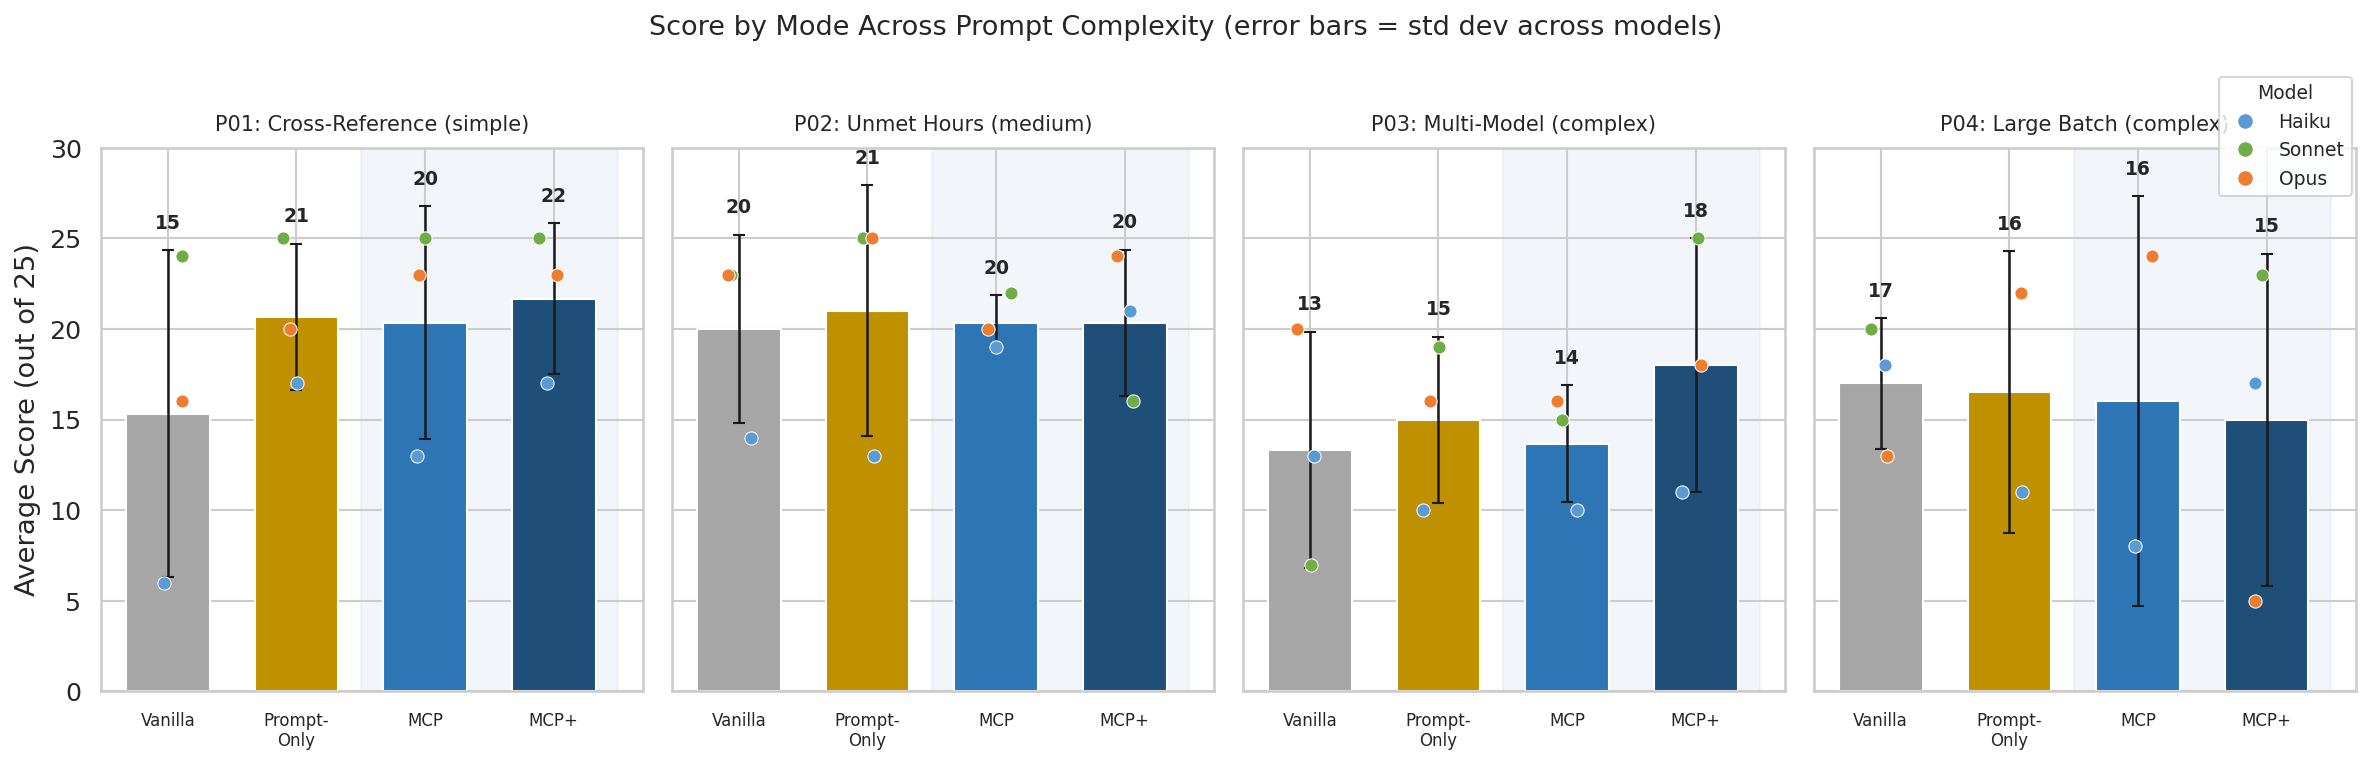

In [13]:
prompt_titles = {
    "01": "P01: Cross-Reference (simple)",
    "02": "P02: Unmet Hours (medium)",
    "03": "P03: Multi-Model (complex)",
    "04": "P04: Large Batch (complex)",
}

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

mode_order_short = ["vanilla", "prompt-only", "mcp-pandas-exec", "mcp-pandas-exec-plus"]
mode_bar_labels = ["Vanilla", "Prompt-\nOnly", "MCP", "MCP+"]
mode_pal = [mode_colors[m] for m in mode_order_short]

for idx, (prompt, ax) in enumerate(zip(["01", "02", "03", "04"], axes)):
    sub = df[df["prompt"] == prompt]

    # Average score per mode (across models)
    avg = sub.groupby("mode_norm")["score"].agg(["mean", "std", "count"]).reindex(mode_order_short)

    x = np.arange(len(mode_order_short))
    bars = ax.bar(x, avg["mean"], color=mode_pal, edgecolor="white", width=0.65,
                  yerr=avg["std"], error_kw={"lw": 1.2, "capsize": 3, "capthick": 1})

    # Individual model dots
    for _, row in sub.iterrows():
        mode_idx = mode_order_short.index(row["mode_norm"]) if row["mode_norm"] in mode_order_short else None
        if mode_idx is not None:
            ax.scatter(mode_idx + np.random.uniform(-0.12, 0.12), row["score"],
                       color=model_colors[row["model"]], s=40, edgecolor="white",
                       linewidth=0.5, zorder=4)

    # Score labels
    for i, m in enumerate(mode_order_short):
        if not pd.isna(avg.loc[m, "mean"]):
            ax.text(i, avg.loc[m, "mean"] + avg.loc[m, "std"] + 1.2,
                    f"{avg.loc[m, 'mean']:.0f}", ha="center", fontsize=9, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(mode_bar_labels, fontsize=8)
    ax.set_title(prompt_titles[prompt], fontsize=10, pad=8)
    ax.set_ylim(0, 30)

    # MCP bracket
    ax.axvspan(1.5, 3.5, alpha=0.06, color="#2E75B6", zorder=0)

    if idx == 0:
        ax.set_ylabel("Average Score (out of 25)")

# Shared legend for model dots
model_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
                         markersize=8, label=m) for m, c in model_colors.items()]
fig.legend(handles=model_handles, title="Model", loc="upper right",
           bbox_to_anchor=(0.99, 0.95), fontsize=9, title_fontsize=9)

fig.suptitle("Score by Mode Across Prompt Complexity (error bars = std dev across models)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("results/graphic_3_mode_by_prompt.png", bbox_inches="tight")
plt.show()

## 4. MCP Score Delta — Per Model

The change in score when switching from vanilla to MCP pandas-exec, shown per-model.  
Green = MCP helped, red = MCP hurt. The effect is model-dependent, not uniform.

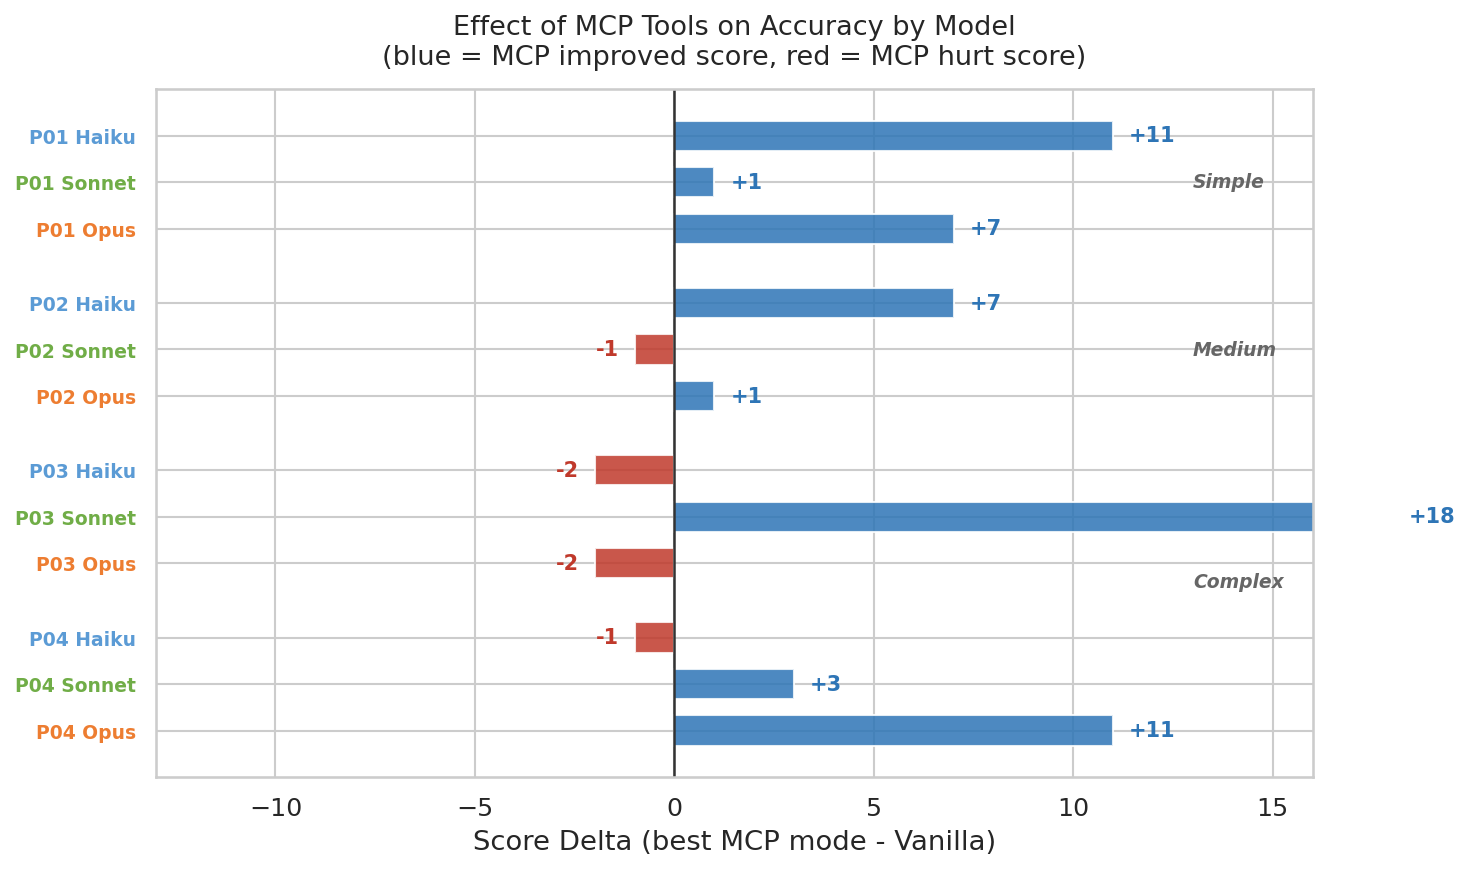

In [14]:
# Compute deltas: best MCP mode minus vanilla for each prompt × model
vanilla_scores = df[df["mode_norm"] == "vanilla"].set_index(["prompt", "model"])["score"]
mcp_scores = df[df["mode_norm"].isin(["mcp-pandas-exec", "mcp-pandas-exec-plus"])] \
    .groupby(["prompt", "model"])["score"].max()  # take best MCP mode

delta = (mcp_scores - vanilla_scores).dropna().reset_index()
delta.columns = ["prompt", "model", "delta"]
delta["complexity"] = delta["prompt"].map(
    {"01": "Simple", "02": "Medium", "03": "Complex", "04": "Complex"})

fig, ax = plt.subplots(figsize=(10, 6))

labels, positions, colors_list = [], [], []
pos = 0
for prompt in ["01", "02", "03", "04"]:
    for model in ["Haiku", "Sonnet", "Opus"]:
        row = delta[(delta["prompt"] == prompt) & (delta["model"] == model)]
        if row.empty:
            continue
        d = row["delta"].values[0]
        bar_color = "#2E75B6" if d >= 0 else "#C0392B"
        ax.barh(pos, d, color=bar_color, edgecolor="white", height=0.65, alpha=0.85)
        ax.text(d + (0.4 if d >= 0 else -0.4), pos,
                f"{d:+.0f}", va="center", ha="left" if d >= 0 else "right",
                fontsize=10, fontweight="bold", color=bar_color)
        labels.append(f"P{prompt} {model}")
        positions.append(pos)
        colors_list.append(model_colors[model])
        pos += 1
    pos += 0.6  # gap between prompt groups

ax.set_yticks(positions)
ax.set_yticklabels(labels, fontsize=9)
for tick_label, color in zip(ax.get_yticklabels(), colors_list):
    tick_label.set_color(color)
    tick_label.set_fontweight("bold")

ax.axvline(0, color="#333", lw=1.2)
ax.set_xlabel("Score Delta (best MCP mode - Vanilla)")
ax.set_title("Effect of MCP Tools on Accuracy by Model\n"
             "(blue = MCP improved score, red = MCP hurt score)",
             fontsize=13, pad=12)

# Complexity brackets on right
bracket_y = {"Simple": (0, 2), "Medium": (3.6, 5.6), "Complex": (7.2, 12)}
for label, (y_start, y_end) in bracket_y.items():
    mid = (y_start + y_end) / 2
    ax.text(13, mid, label, fontsize=9, color="#666", fontweight="bold",
            ha="left", va="center", style="italic")

ax.invert_yaxis()
ax.set_xlim(-13, 16)
plt.tight_layout()
plt.savefig("results/graphic_4_mcp_delta.png", bbox_inches="tight")
plt.show()

## 5. Speed vs. Accuracy — Colored by Mode

Wall time vs. score with mode as the primary color axis and model as shape.  
Shows whether MCP tools buy you speed, accuracy, or neither.

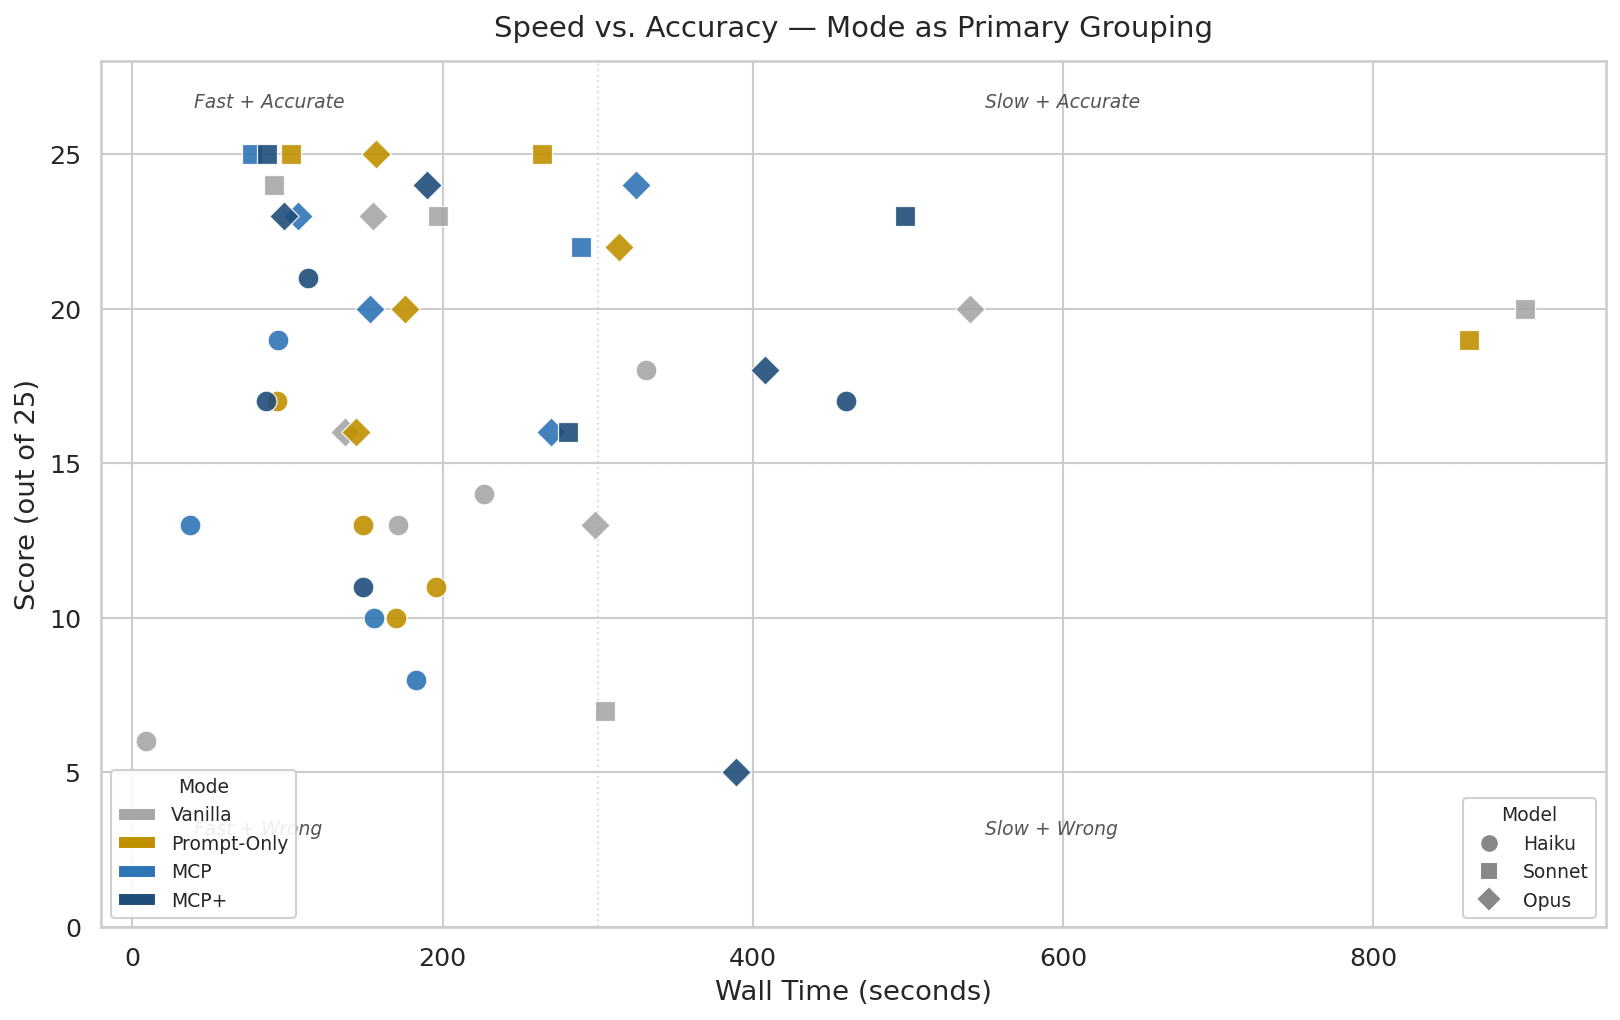

In [15]:
df_timed = df.dropna(subset=["time"]).copy()

model_markers = {"Haiku": "o", "Sonnet": "s", "Opus": "D"}

fig, ax = plt.subplots(figsize=(11, 7))

for mode in mode_order_short:
    for model in ["Haiku", "Sonnet", "Opus"]:
        subset = df_timed[(df_timed["mode_norm"] == mode) & (df_timed["model"] == model)]
        if subset.empty:
            continue
        ax.scatter(subset["time"], subset["score"],
                   c=mode_colors[mode], marker=model_markers[model], s=100,
                   edgecolors="white", linewidths=0.6, zorder=3, alpha=0.9)

# Quadrant lines
ax.axhline(15, color="#ddd", ls=":", lw=1, zorder=0)
ax.axvline(300, color="#ddd", ls=":", lw=1, zorder=0)
ax.text(40, 26.5, "Fast + Accurate", fontsize=9, color="#555", style="italic")
ax.text(550, 26.5, "Slow + Accurate", fontsize=9, color="#555", style="italic")
ax.text(40, 3, "Fast + Wrong", fontsize=9, color="#555", style="italic")
ax.text(550, 3, "Slow + Wrong", fontsize=9, color="#555", style="italic")

# Mode legend (color = mode)
mode_handles = [mpatches.Patch(facecolor=mode_colors[m], label=l, edgecolor="white")
                for m, l in zip(mode_order_short, ["Vanilla", "Prompt-Only", "MCP", "MCP+"])]
# Model legend (shape = model)
model_handles = [Line2D([0], [0], marker=model_markers[m], color="w",
                         markerfacecolor="#888", markersize=9, label=m)
                 for m in ["Haiku", "Sonnet", "Opus"]]

leg1 = ax.legend(handles=mode_handles, title="Mode", loc="lower left",
                 framealpha=0.9, fontsize=9, title_fontsize=9)
ax.add_artist(leg1)
ax.legend(handles=model_handles, title="Model", loc="lower right",
          framealpha=0.9, fontsize=9, title_fontsize=9)

ax.set_xlabel("Wall Time (seconds)")
ax.set_ylabel("Score (out of 25)")
ax.set_title("Speed vs. Accuracy — Mode as Primary Grouping", fontsize=14, pad=12)
ax.set_xlim(-20, 950)
ax.set_ylim(0, 28)
plt.tight_layout()
plt.savefig("results/graphic_5_scatter.png", bbox_inches="tight")
plt.show()

## 6. Failure Modes — By Mode Category

Where do failures (score < 15) cluster? Split by MCP / No MCP, with failure type breakdown.

/tmp/ipykernel_13058/2635498968.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pass_fail = df.groupby("mode_norm").apply(


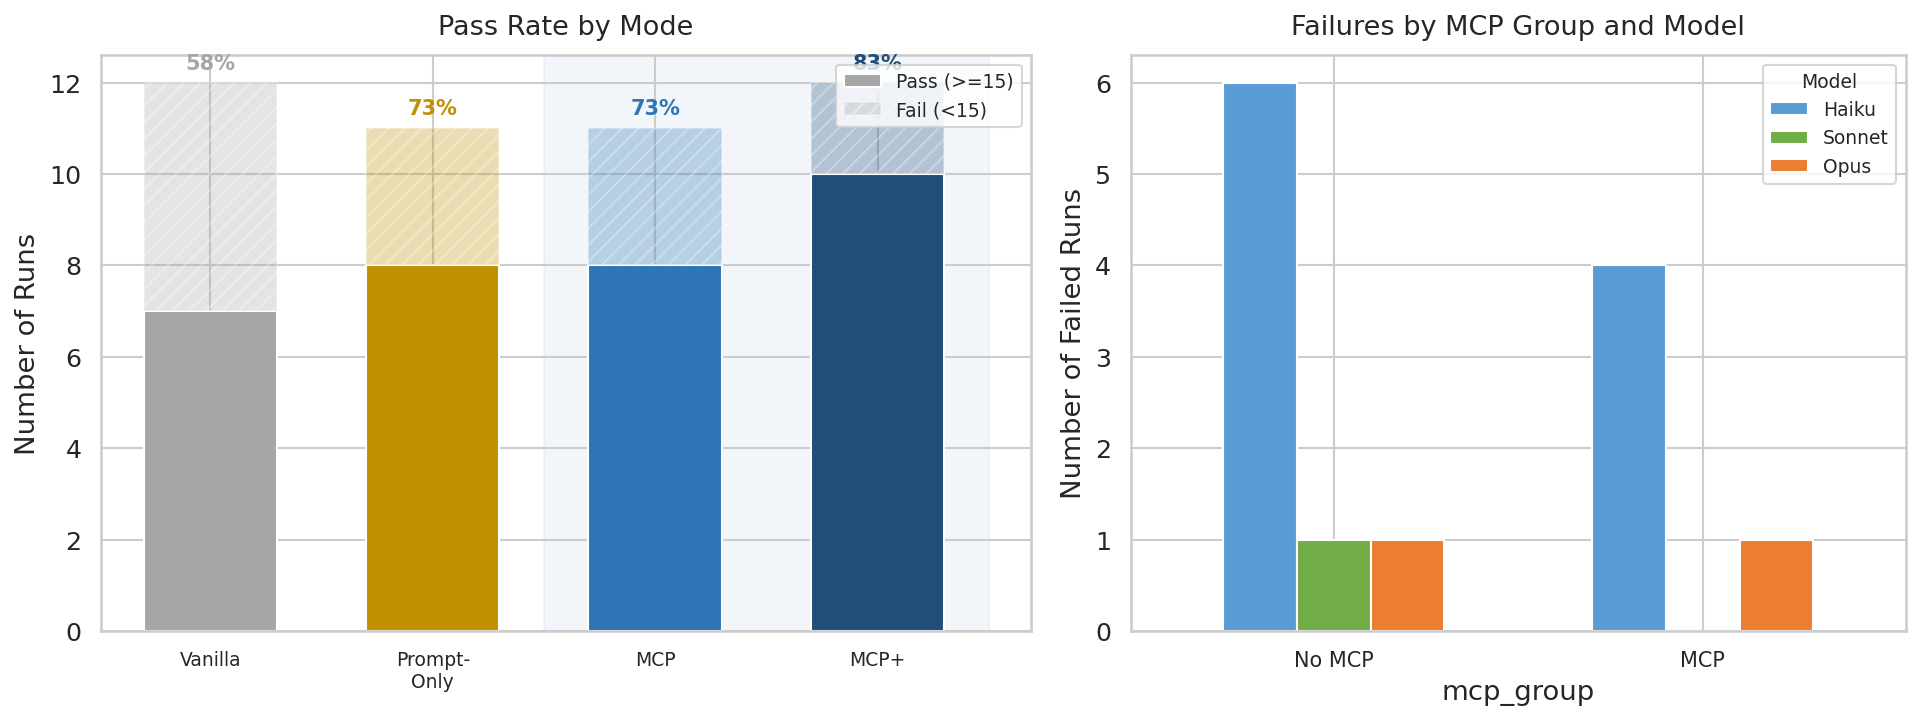

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.2, 1]})

# ── Left: Pass/fail counts by mode ──
pass_fail = df.groupby("mode_norm").apply(
    lambda g: pd.Series({"Pass": (g["score"] >= 15).sum(),
                          "Fail": (g["score"] < 15).sum(),
                          "Total": len(g)})).reindex(mode_order_short)

x = np.arange(len(mode_order_short))
ax1.bar(x, pass_fail["Pass"], color=[mode_colors[m] for m in mode_order_short],
        edgecolor="white", width=0.6, label="Pass (>=15)")
ax1.bar(x, pass_fail["Fail"], bottom=pass_fail["Pass"],
        color=[mode_colors[m] for m in mode_order_short], alpha=0.3,
        edgecolor="white", width=0.6, label="Fail (<15)", hatch="///")

for i, m in enumerate(mode_order_short):
    total = pass_fail.loc[m, "Total"]
    pct = pass_fail.loc[m, "Pass"] / total * 100
    ax1.text(i, total + 0.3, f"{pct:.0f}%", ha="center", fontsize=10,
             fontweight="bold", color=mode_colors[m])

ax1.set_xticks(x)
ax1.set_xticklabels(mode_bar_labels, fontsize=9)
ax1.set_ylabel("Number of Runs")
ax1.set_title("Pass Rate by Mode", fontsize=13, pad=10)
ax1.legend(fontsize=9, loc="upper right")

# MCP bracket
ax1.axvspan(1.5, 3.5, alpha=0.06, color="#2E75B6", zorder=0)

# ── Right: Failure count by mode × model ──
fails = df[df["score"] < 15].copy()
fail_ct = fails.groupby(["mcp_group", "model"]).size().unstack(fill_value=0)
fail_ct = fail_ct.reindex(index=["No MCP", "MCP"],
                           columns=["Haiku", "Sonnet", "Opus"]).fillna(0)

fail_ct.plot(kind="bar", ax=ax2, color=[model_colors[m] for m in fail_ct.columns],
             edgecolor="white", width=0.6)
ax2.set_xticklabels(["No MCP", "MCP"], rotation=0, fontsize=10)
ax2.set_ylabel("Number of Failed Runs")
ax2.set_title("Failures by MCP Group and Model", fontsize=13, pad=10)
ax2.legend(title="Model", fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig("results/graphic_6_failures.png", bbox_inches="tight")
plt.show()

## 7. The Takeaway — Mode Average Scores with Model Breakdown

One clean chart for the slide deck: average score per mode, with model dots overlaid to show variance.

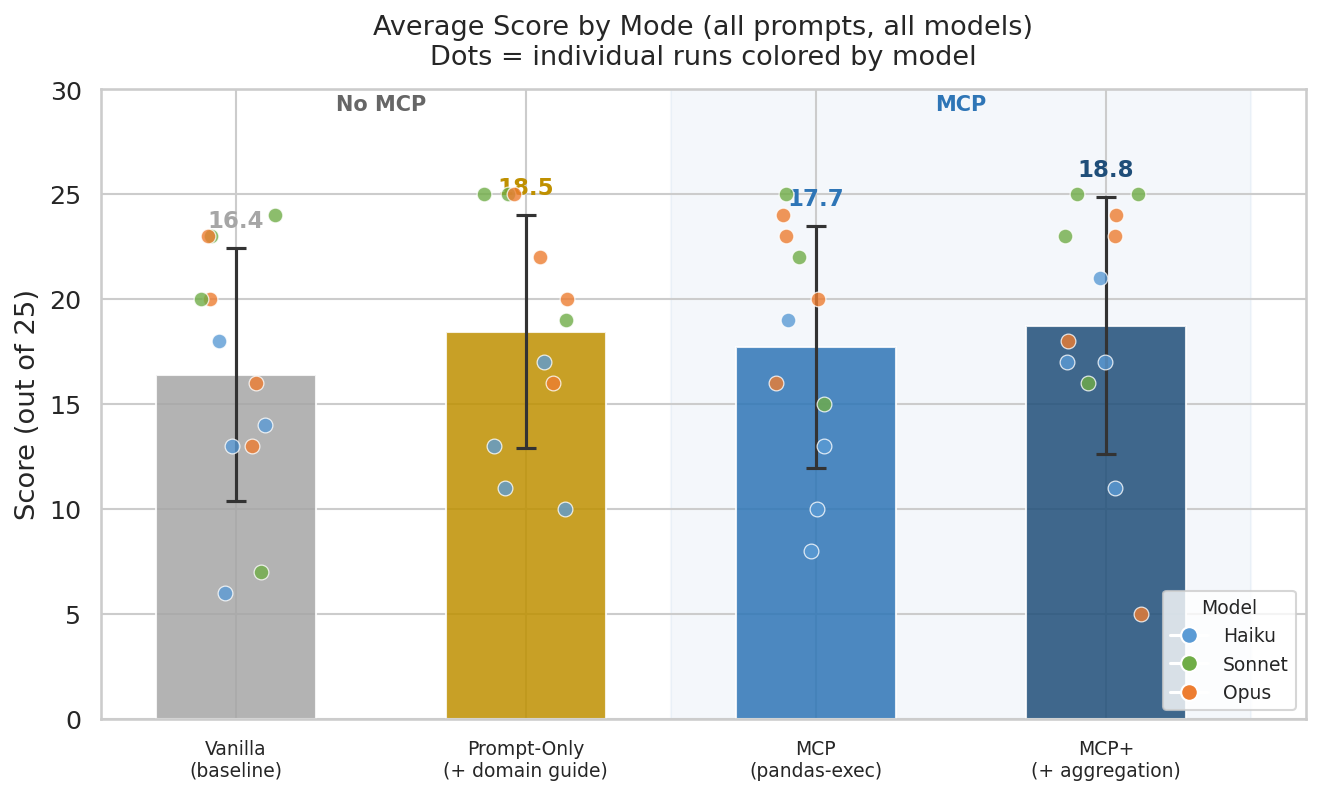


── Summary Stats ──

Overall: MCP avg = 18.3, No MCP avg = 17.4
  vanilla                    avg=16.4  std=6.0  n=12
  prompt-only                avg=18.5  std=5.6  n=11
  mcp-pandas-exec            avg=17.7  std=5.8  n=11
  mcp-pandas-exec-plus       avg=18.8  std=6.1  n=12


In [17]:
fig, ax = plt.subplots(figsize=(9, 5.5))

# Compute per-mode averages
mode_avg = df.groupby("mode_norm")["score"].agg(["mean", "std", "count"]).reindex(mode_order_short)

x = np.arange(len(mode_order_short))
bars = ax.bar(x, mode_avg["mean"], color=[mode_colors[m] for m in mode_order_short],
              edgecolor="white", width=0.55, zorder=2, alpha=0.85)

# Error bars
ax.errorbar(x, mode_avg["mean"], yerr=mode_avg["std"], fmt="none",
            ecolor="#333", elinewidth=1.5, capsize=5, capthick=1.5, zorder=3)

# Individual model dots with jitter
np.random.seed(42)
for _, row in df.iterrows():
    mode_idx = mode_order_short.index(row["mode_norm"])
    jitter = np.random.uniform(-0.15, 0.15)
    ax.scatter(mode_idx + jitter, row["score"],
               color=model_colors[row["model"]], s=50, edgecolor="white",
               linewidth=0.6, zorder=4, alpha=0.8)

# Score labels
for i, m in enumerate(mode_order_short):
    ax.text(i, mode_avg.loc[m, "mean"] + mode_avg.loc[m, "std"] + 1,
            f"{mode_avg.loc[m, 'mean']:.1f}", ha="center", fontsize=11,
            fontweight="bold", color=mode_colors[m])

ax.set_xticks(x)
ax.set_xticklabels(["Vanilla\n(baseline)", "Prompt-Only\n(+ domain guide)",
                     "MCP\n(pandas-exec)", "MCP+\n(+ aggregation)"], fontsize=9)
ax.set_ylabel("Score (out of 25)")
ax.set_title("Average Score by Mode (all prompts, all models)\n"
             "Dots = individual runs colored by model", fontsize=13, pad=12)
ax.set_ylim(0, 30)

# MCP highlight
ax.axvspan(1.5, 3.5, alpha=0.05, color="#2E75B6", zorder=0)
ax.text(2.5, 29, "MCP", fontsize=10, ha="center", color="#2E75B6", fontweight="bold")
ax.text(0.5, 29, "No MCP", fontsize=10, ha="center", color="#666", fontweight="bold")

# Model legend
model_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
                         markersize=8, label=m) for m, c in model_colors.items()]
ax.legend(handles=model_handles, title="Model", loc="lower right",
          fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig("results/graphic_7_takeaway.png", bbox_inches="tight")
plt.show()

# Print summary stats
print("\n── Summary Stats ──")
print(f"\nOverall: MCP avg = {df[df['mcp_group']=='MCP']['score'].mean():.1f}, "
      f"No MCP avg = {df[df['mcp_group']=='No MCP']['score'].mean():.1f}")
for m in mode_order_short:
    sub = df[df["mode_norm"] == m]
    print(f"  {m:25s}  avg={sub['score'].mean():.1f}  std={sub['score'].std():.1f}  n={len(sub)}")